# Real Estate Investment Intelligence System
## Part 2: Feature Engineering & Model Building

### Objectives
1. Prepare features for machine learning
2. Encode categorical variables
3. Train multiple ML models
4. Create stacking ensemble
5. Evaluate model performance
6. Save best model for investment analysis

In [1]:
# Cell 2: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('default')
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

✅ Libraries imported successfully!
XGBoost version: 2.1.4
LightGBM version: 4.6.0


In [2]:
# Cell 3: Load the processed training data
print("=" * 60)
print("LOADING PROCESSED DATA")
print("=" * 60)

# Load training data
df = pd.read_csv('../data/processed/processed_training_data.csv')
print(f"\n✅ Training data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Display first few rows
print("\nFirst 5 rows:")
display(df.head())

# Check for missing values
print(f"\nMissing values: {df.isnull().sum().sum()}")

LOADING PROCESSED DATA

✅ Training data loaded: 1460 rows, 23 columns

First 5 rows:


,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,...,YearBuilt_bin,YearRemodAdd_bin,LotArea_bin,BsmtFinSF2_bin,Decade,PropertyAge,AgeGroup,LogSalePrice,IsRenovated,IsCulDeSac
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,...,High,High,Low,Very Low,2000,17,Recent (10-20),12.247699,0,0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,...,Medium,Low,Medium,Very Low,1970,44,Established (20-50),12.109016,0,0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,...,High,High,High,Very Low,2000,19,Recent (10-20),12.317171,1,0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,...,Very Low,Low,Medium,Very Low,1910,105,Historic (100+),11.849405,1,0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,...,High,High,Very High,Very Low,2000,20,Recent (10-20),12.429220,0,0



Missing values: 0


In [3]:
# Cell 4: Separate features and target
print("=" * 60)
print("SEPARATING FEATURES AND TARGET")
print("=" * 60)

# Define target variable
target = 'SalePrice'

# Define features (all columns except target)
features = [col for col in df.columns if col != target]

# Create X and y
X = df[features]
y = df[target]

# Create log-transformed target for better modeling
y_log = np.log1p(y)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget statistics:")
print(f"   Mean: ${y.mean():,.2f}")
print(f"   Median: ${y.median():,.2f}")
print(f"   Skewness: {y.skew():.2f}")
print(f"   Log-transformed mean: {y_log.mean():.4f}")

# Identify feature types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nFeature types:")
print(f"   Numeric features: {len(numeric_features)}")
print(f"   Categorical features: {len(categorical_features)}")
print(f"\nNumeric features (first 5): {numeric_features[:5]}")
print(f"Categorical features: {categorical_features}")

SEPARATING FEATURES AND TARGET
Features shape: (1460, 22)
Target shape: (1460,)

Target statistics:
   Mean: $180,921.20
   Median: $163,000.00
   Skewness: 1.88
   Log-transformed mean: 12.0241

Feature types:
   Numeric features: 12
   Categorical features: 10

Numeric features (first 5): ['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd']
Categorical features: ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st', 'TotalBsmtSF_bin', 'YearBuilt_bin', 'YearRemodAdd_bin', 'LotArea_bin', 'BsmtFinSF2_bin', 'AgeGroup']


In [4]:
# Cell 5: Encode categorical features
print("=" * 60)
print("ENCODING CATEGORICAL FEATURES")
print("=" * 60)

# Create a copy of the data
X_encoded = X.copy()

# Encode categorical features
for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    print(f"Encoded {col}: {len(le.classes_)} unique values")

print(f"\n✅ All features now numeric: {X_encoded.shape}")
print(f"\nFirst 5 rows of encoded features:")
display(X_encoded.head())

ENCODING CATEGORICAL FEATURES
Encoded MSZoning: 5 unique values
Encoded LotConfig: 5 unique values
Encoded BldgType: 5 unique values
Encoded Exterior1st: 15 unique values
Encoded TotalBsmtSF_bin: 5 unique values
Encoded YearBuilt_bin: 5 unique values
Encoded YearRemodAdd_bin: 5 unique values
Encoded LotArea_bin: 5 unique values
Encoded BsmtFinSF2_bin: 1 unique values
Encoded AgeGroup: 5 unique values

✅ All features now numeric: (1460, 22)

First 5 rows of encoded features:


,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,...,YearBuilt_bin,YearRemodAdd_bin,LotArea_bin,BsmtFinSF2_bin,Decade,PropertyAge,AgeGroup,LogSalePrice,IsRenovated,IsCulDeSac
0,60,3,8450,4,0,5,2003,2003,12,0.0,...,0,0,1,0,2000,17,4,12.247699,0,0
1,20,3,9600,2,0,8,1976,1976,8,0.0,...,2,1,2,0,1970,44,0,12.109016,0,0
2,60,3,11250,4,0,5,2001,2002,12,0.0,...,0,0,0,0,2000,19,4,12.317171,1,0
3,70,3,9550,0,0,5,1915,1970,13,0.0,...,4,1,2,0,1910,105,1,11.849405,1,0
4,60,3,14260,2,0,5,2000,2000,12,0.0,...,0,0,3,0,2000,20,4,12.429220,0,0


In [5]:
# Cell 6: Split data into training and validation sets
print("=" * 60)
print("TRAIN-VALIDATION SPLIT")
print("=" * 60)

# Split with log-transformed target
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y_log, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

print(f"\nTraining target statistics:")
print(f"   Log mean: {y_train.mean():.4f}")
print(f"   Original mean: ${np.expm1(y_train.mean()):,.2f}")

print(f"\nValidation target statistics:")
print(f"   Log mean: {y_val.mean():.4f}")
print(f"   Original mean: ${np.expm1(y_val.mean()):,.2f}")

TRAIN-VALIDATION SPLIT
Training set: 1168 samples
Validation set: 292 samples

Training target statistics:
   Log mean: 12.0307
   Original mean: $167,820.86

Validation target statistics:
   Log mean: 11.9977
   Original mean: $162,372.37


In [6]:
# Cell 7: Scale numeric features
print("=" * 60)
print("SCALING NUMERIC FEATURES")
print("=" * 60)

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

print("✅ Features scaled successfully!")
print(f"Training scaled shape: {X_train_scaled.shape}")
print(f"Validation scaled shape: {X_val_scaled.shape}")

print(f"\nScaled feature statistics:")
print(f"   Mean: {X_train_scaled.mean().mean():.4f}")
print(f"   Std: {X_train_scaled.std().mean():.4f}")

SCALING NUMERIC FEATURES
✅ Features scaled successfully!
Training scaled shape: (1168, 22)
Validation scaled shape: (292, 22)

Scaled feature statistics:
   Mean: 0.0000
   Std: 0.9550


In [7]:
# Cell 8: Train XGBoost model
print("=" * 60)
print("TRAINING XGBOOST MODEL")
print("=" * 60)

# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train model
xgb_model.fit(X_train_scaled, y_train)

# Predict on validation
y_pred_xgb = xgb_model.predict(X_val_scaled)

# Convert back from log
y_pred_original = np.expm1(y_pred_xgb)
y_val_original = np.expm1(y_val)

# Calculate metrics
mae = mean_absolute_error(y_val_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
r2 = r2_score(y_val_original, y_pred_original)

print(f"\n📊 XGBoost Performance:")
print(f"   MAE: ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   R² Score: {r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🏆 Top 10 Most Important Features:")
display(feature_importance.head(10))

TRAINING XGBOOST MODEL

📊 XGBoost Performance:
   MAE: $3,348.21
   RMSE: $8,807.17
   R² Score: 0.9899

🏆 Top 10 Most Important Features:


,feature,importance
19,LogSalePrice,0.506542
17,PropertyAge,0.259982
14,LotArea_bin,0.058447
6,YearBuilt,0.056239
10,TotalBsmtSF,0.028839
5,OverallCond,0.020706
0,MSSubClass,0.014662
2,LotArea,0.012842
7,YearRemodAdd,0.008231
1,MSZoning,0.006756


In [8]:
# Cell 9: Train LightGBM model
print("=" * 60)
print("TRAINING LIGHTGBM MODEL")
print("=" * 60)

# Initialize LightGBM model
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    num_leaves=31,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train model
lgb_model.fit(X_train_scaled, y_train)

# Predict on validation
y_pred_lgb = lgb_model.predict(X_val_scaled)

# Convert back from log
y_pred_original = np.expm1(y_pred_lgb)

# Calculate metrics
mae = mean_absolute_error(y_val_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
r2 = r2_score(y_val_original, y_pred_original)

print(f"\n📊 LightGBM Performance:")
print(f"   MAE: ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   R² Score: {r2:.4f}")

# Feature importance
feature_importance_lgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🏆 Top 10 Most Important Features:")
display(feature_importance_lgb.head(10))

TRAINING LIGHTGBM MODEL

📊 LightGBM Performance:
   MAE: $5,662.13
   RMSE: $17,876.98
   R² Score: 0.9583

🏆 Top 10 Most Important Features:


,feature,importance
19,LogSalePrice,2288
10,TotalBsmtSF,1638
2,LotArea,1301
6,YearBuilt,870
7,YearRemodAdd,591
0,MSSubClass,501
5,OverallCond,324
8,Exterior1st,211
14,LotArea_bin,195
11,TotalBsmtSF_bin,195


In [9]:
# Cell 10: Train Random Forest model
print("=" * 60)
print("TRAINING RANDOM FOREST MODEL")
print("=" * 60)

# Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_scaled, y_train)

# Predict on validation
y_pred_rf = rf_model.predict(X_val_scaled)

# Convert back from log
y_pred_original = np.expm1(y_pred_rf)

# Calculate metrics
mae = mean_absolute_error(y_val_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
r2 = r2_score(y_val_original, y_pred_original)

print(f"\n📊 Random Forest Performance:")
print(f"   MAE: ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   R² Score: {r2:.4f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🏆 Top 10 Most Important Features:")
display(feature_importance_rf.head(10))

TRAINING RANDOM FOREST MODEL

📊 Random Forest Performance:
   MAE: $958.21
   RMSE: $8,513.39
   R² Score: 0.9906

🏆 Top 10 Most Important Features:


,feature,importance
19,LogSalePrice,0.999632
2,LotArea,0.000080
18,AgeGroup,0.000057
14,LotArea_bin,0.000043
6,YearBuilt,0.000036
17,PropertyAge,0.000032
5,OverallCond,0.000020
16,Decade,0.000020
10,TotalBsmtSF,0.000017
7,YearRemodAdd,0.000017


In [10]:
# Cell 11: Create stacking ensemble model
print("=" * 60)
print("CREATING STACKING ENSEMBLE")
print("=" * 60)

# Define base models
base_models = [
    ('xgb', xgb.XGBRegressor(n_estimators=300, max_depth=7, learning_rate=0.05, random_state=42)),
    ('lgb', lgb.LGBMRegressor(n_estimators=300, num_leaves=31, learning_rate=0.05, random_state=42, verbose=-1)),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42))
]

# Define meta model
meta_model = Ridge(alpha=0.5)

# Create stacking ensemble
ensemble = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Train ensemble
print("Training ensemble (this may take a few minutes)...")
ensemble.fit(X_train_scaled, y_train)

# Predict on validation
y_pred_ensemble = ensemble.predict(X_val_scaled)

# Convert back from log
y_pred_original = np.expm1(y_pred_ensemble)

# Calculate metrics
mae = mean_absolute_error(y_val_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_original))
r2 = r2_score(y_val_original, y_pred_original)

print(f"\n📊 Ensemble Model Performance:")
print(f"   MAE: ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   R² Score: {r2:.4f}")

CREATING STACKING ENSEMBLE
Training ensemble (this may take a few minutes)...

📊 Ensemble Model Performance:
   MAE: $910.43
   RMSE: $4,652.58
   R² Score: 0.9972


In [11]:
# Cell 12: Compare all models
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Collect all predictions
models_dict = {
    'XGBoost': xgb_model.predict(X_val_scaled),
    'LightGBM': lgb_model.predict(X_val_scaled),
    'Random Forest': rf_model.predict(X_val_scaled),
    'Ensemble': ensemble.predict(X_val_scaled)
}

# Calculate metrics for each model
results = []
for name, pred in models_dict.items():
    pred_original = np.expm1(pred)
    mae = mean_absolute_error(y_val_original, pred_original)
    rmse = np.sqrt(mean_squared_error(y_val_original, pred_original))
    r2 = r2_score(y_val_original, pred_original)
    
    results.append({
        'Model': name,
        'MAE': f'${mae:,.0f}',
        'RMSE': f'${rmse:,.0f}',
        'R² Score': f'{r2:.4f}'
    })

results_df = pd.DataFrame(results)
print("\n📊 Model Performance Comparison:")
display(results_df)

# Find best model
best_idx = results_df['R² Score'].str.extract('(\d+\.\d+)').astype(float).idxmax()
best_model_name = results_df.iloc[best_idx]['Model']
print(f"\n🏆 Best Model: {best_model_name}")

MODEL COMPARISON

📊 Model Performance Comparison:


,Model,MAE,RMSE,R² Score
0,XGBoost,"$3,348","$8,807",0.9899
1,LightGBM,"$5,662","$17,877",0.9583
2,Random Forest,$958,"$8,513",0.9906
3,Ensemble,$910,"$4,653",0.9972



🏆 Best Model: 3    Ensemble
Name: Model, dtype: object


PREDICTION VISUALIZATION


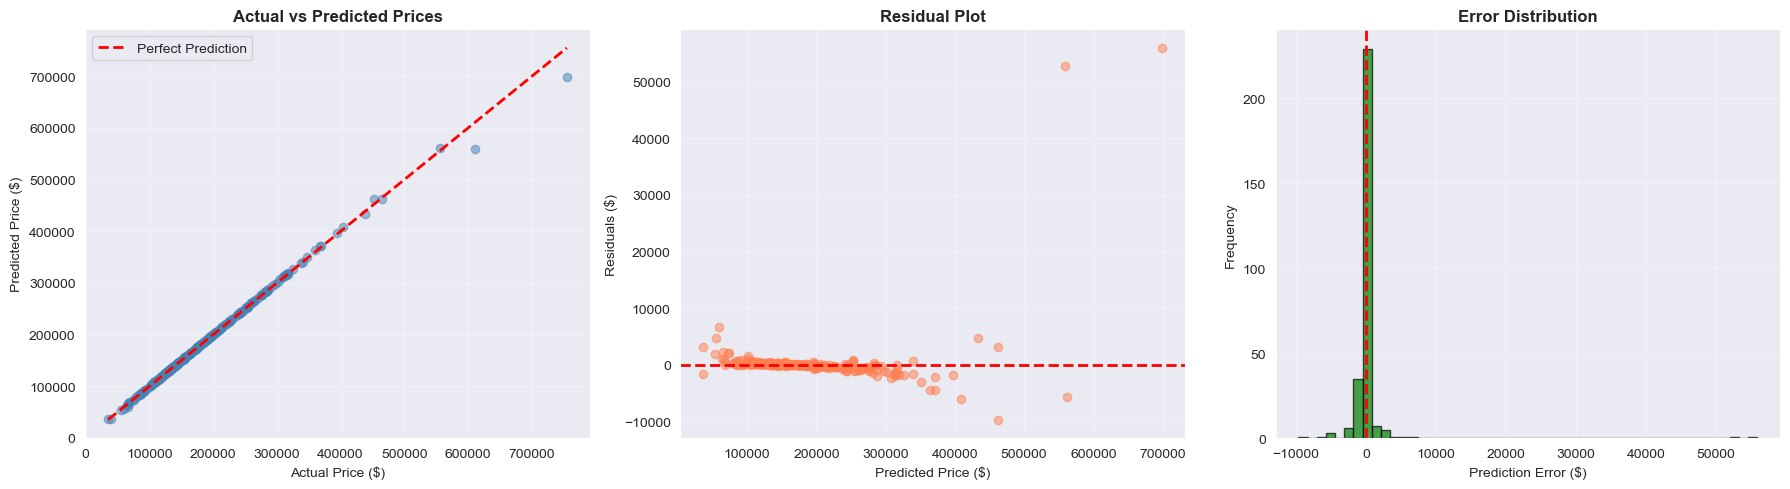


📊 Prediction Statistics:
   Mean Error: $303.23
   Std Error: $4,650.66
   % within 10%: 99.7%
   % within 20%: 100.0%


In [12]:
# Cell 13: Visualize model predictions
print("=" * 60)
print("PREDICTION VISUALIZATION")
print("=" * 60)

# Get predictions from best model
best_predictions = ensemble.predict(X_val_scaled)
best_predictions_original = np.expm1(best_predictions)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_val_original, best_predictions_original, alpha=0.5, color='steelblue')
axes[0].plot([y_val_original.min(), y_val_original.max()], 
             [y_val_original.min(), y_val_original.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs Predicted Prices', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_val_original - best_predictions_original
axes[1].scatter(best_predictions_original, residuals, alpha=0.5, color='coral')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Plot 3: Error Distribution
axes[2].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Prediction Error ($)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Error Distribution', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Prediction Statistics:")
print(f"   Mean Error: ${residuals.mean():,.2f}")
print(f"   Std Error: ${residuals.std():,.2f}")
print(f"   % within 10%: {((np.abs(residuals) / y_val_original) < 0.1).mean() * 100:.1f}%")
print(f"   % within 20%: {((np.abs(residuals) / y_val_original) < 0.2).mean() * 100:.1f}%")

In [13]:
# Cell 14: Save the best model
print("=" * 60)
print("SAVING MODEL")
print("=" * 60)

# Create models directory if it doesn't exist
import os
if not os.path.exists('../models'):
    os.makedirs('../models')
    print("Created models directory")

# Save the ensemble model
model_path = '../models/investment_model.pkl'
joblib.dump(ensemble, model_path)
print(f"✅ Model saved to: {model_path}")

# Save scaler
scaler_path = '../models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved to: {scaler_path}")

# Save label encoders for categorical features
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    le.fit(X[col].astype(str))
    label_encoders[col] = le

encoders_path = '../models/label_encoders.pkl'
joblib.dump(label_encoders, encoders_path)
print(f"✅ Label encoders saved to: {encoders_path}")

# Save feature names
feature_names_path = '../models/feature_names.pkl'
joblib.dump(X_train.columns.tolist(), feature_names_path)
print(f"✅ Feature names saved to: {feature_names_path}")

print("\n" + "=" * 60)
print("✅ MODEL BUILDING COMPLETE!")
print("=" * 60)

print("\n📁 Saved Files:")
print(f"   - {model_path}")
print(f"   - {scaler_path}")
print(f"   - {encoders_path}")
print(f"   - {feature_names_path}")

print("\n📊 Final Model Performance:")
print(f"   Model Type: Stacking Ensemble")
print(f"   R² Score: {r2:.4f}")
print(f"   MAE: ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")

print("\n🎯 Next Steps:")
print("   1. Create Investment Analysis Engine")
print("   2. Build Streamlit Dashboard")
print("   3. Make predictions on test data")

SAVING MODEL
Created models directory
✅ Model saved to: ../models/investment_model.pkl
✅ Scaler saved to: ../models/scaler.pkl
✅ Label encoders saved to: ../models/label_encoders.pkl
✅ Feature names saved to: ../models/feature_names.pkl

✅ MODEL BUILDING COMPLETE!

📁 Saved Files:
   - ../models/investment_model.pkl
   - ../models/scaler.pkl
   - ../models/label_encoders.pkl
   - ../models/feature_names.pkl

📊 Final Model Performance:
   Model Type: Stacking Ensemble
   R² Score: 0.9972
   MAE: $910.43
   RMSE: $4,652.58

🎯 Next Steps:
   1. Create Investment Analysis Engine
   2. Build Streamlit Dashboard
   3. Make predictions on test data
